# Part 8: Joint Individual Research
## MLP Optimization and Manual Reproduction of the Forward Pass (Excel/Google Sheets)

**Dataset:** Transportation Statistics Yearbook - Traffic Accidents (Ecuador), [datosabiertos.gob.ec](https://datosabiertos.gob.ec/)

**Input variables (X):** `MONTH`, `DAY`, `HOUR`, `PROVINCE`, `CANTON`, `ZONE` (encoded with `pd.get_dummies()`)

**Target variable (y):** `CAUSE` (multiclass classification of the accident cause)

This notebook develops in detail **Part 8** of the guide (`MLP_Classification_Pipeline_and_Excel.ipynb`): hyperparameter optimization of the `MLPClassifier`, exporting the best model's parameters, and the manual mathematical reproduction -outside of Python- of the forward pass for a test observation.

> **Note:** this notebook has already been run from start to finish. Hyperparameter optimization (Section 2) was done exclusively with `RandomizedSearchCV`; `GridSearchCV` was not used.

## Objectives of this notebook

- Optimize the `MLPClassifier` with `RandomizedSearchCV`, exploring at least `hidden_layer_sizes` and `activation`.
- Compare the optimized model against the base model `(20, 10)` using exactly the same train/test split.
- Extract and export to Excel the best model's mathematical parameters: `StandardScaler` means/scales, weight matrices (`coefs_`), bias vectors (`intercepts_`), and the class order (`classes_`).
- Document, formula by formula, how to reproduce the forward pass (standardization -> hidden layers -> softmax) in Excel or Google Sheets.
- Write up the theoretical deliverables: comparison table, technical limitation + proposed improvement, and causality analysis.

## Section 0: Prerequisites - expected variables

The following cell loads the raw dataset into `df` (it must already be clean, with no nulls, with columns `MONTH`, `DAY`, `HOUR`, `PROVINCE`, `CANTON`, `ZONE`, `CAUSE`) and builds `X` (with `pd.get_dummies()`), `y`, and the train/test split with `random_state=42`, so that **the base model and the optimized model are trained and evaluated on exactly the same data**.

In [48]:
import pandas as pd
import numpy as np


df = pd.read_csv('../csv/inec_anuario-de-estadisticas-de-transporte_siniestros-de-transito_2019.csv', sep=';', low_memory=False)
df.head()

,MES,DIA,HORA,PROVINCIA,CANTON,ZONA,NUM_FALLECIDO,NUM_LESIONADO,TOTAL_VICTIMAS,CLASE,CAUSA
0,ENERO,MARTES,11:00 A 11:59,IMBABURA,OTAVALO,URBANA,0,0,0,PÉRDIDA DE PISTA,IMPERICIA E IMPRUDENCIA DEL CONDUCTOR
1,ENERO,MARTES,23:00 A 23:59,IMBABURA,IBARRA,RURAL,0,0,0,OTROS,OTRAS CAUSAS
2,ENERO,MARTES,12:00 A 12:59,TUNGURAHUA,AMBATO,URBANA,0,3,3,CHOQUES,NO RESPETA LAS SEÑALES DE TRÁNSITO
3,ENERO,MARTES,07:00 A 07:59,TUNGURAHUA,AMBATO,RURAL,0,1,1,ATROPELLOS,EMBRIAGUEZ O DROGA
4,ENERO,MARTES,04:00 A 04:59,PICHINCHA,DISTRITO METROPOLITANO DE QUITO,URBANA,0,0,0,ESTRELLAMIENTOS,EXCESO VELOCIDAD


In [49]:
FEATURES = ["MES", "DIA", "HORA", "PROVINCIA", "CANTON", "ZONA"]
TARGET = "CAUSA"

# one hot encoding
X = pd.get_dummies(df[FEATURES], columns=FEATURES)
y = df[TARGET]

print("Shape of X (after get_dummies):", X.shape)
print("Number of classes in y:", y.nunique())
print(y.value_counts())


Shape of X (after get_dummies): (24595, 241)
Number of classes in y: 10
CAUSA
IMPERICIA E IMPRUDENCIA DEL CONDUCTOR    11823
EXCESO VELOCIDAD                          4006
NO RESPETA LAS SEÑALES DE TRÁNSITO        3106
EMBRIAGUEZ O DROGA                        1822
MAL REBASAMIENTO INVADIR CARRIL           1768
IMPRUDENCIA  DEL PEATÓN                   1250
FACTORES CLIMÁTICOS                        234
MAL ESTADO DE LA VÍA                       222
OTRAS CAUSAS                               194
DAÑOS MECÁNICOS                            170
Name: count, dtype: int64


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (19676, 241)  Test: (4919, 241)


## Section 1: Base model `(20, 10)` - baseline for comparison

Before optimizing, we train the same base model used in the main notebook (`hidden_layer_sizes=(20, 10)`, `activation='relu'`) on this train/test split. Its metrics will be the **Base** row of the comparison table in Section 5.

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import time

# 2 hidden layers
baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(20, 10),
        activation="relu",
        max_iter=1000,
        random_state=42,
    )),
])

baseline_pipeline.fit(X_train, y_train)

y_pred_base = baseline_pipeline.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_base)
baseline_macro_f1 = f1_score(y_test, y_pred_base, average="macro")


def count_mlp_parameters(mlp_classifier):
    # Total number of trainable parameters (weights + biases) of an MLPClassifier
    n_weights = sum(w.size for w in mlp_classifier.coefs_)
    n_biases = sum(b.size for b in mlp_classifier.intercepts_)
    return n_weights + n_biases


baseline_n_params = count_mlp_parameters(baseline_pipeline.named_steps["classifier"])

print(f"[BASE] Accuracy: {baseline_accuracy:.4f}")
print(f"[BASE] Macro F1-score: {baseline_macro_f1:.4f}")
print(f"[BASE] Total number of parameters: {baseline_n_params}")
print("\nClassification report (BASE):\n")
print(classification_report(y_test, y_pred_base))


[BASE] Accuracy: 0.5389
[BASE] Macro F1-score: 0.1913
[BASE] Total number of parameters: 5160

Classification report (BASE):

                                       precision    recall  f1-score   support

                      DAÑOS MECÁNICOS       0.00      0.00      0.00        34
                   EMBRIAGUEZ O DROGA       0.26      0.14      0.18       364
                     EXCESO VELOCIDAD       0.40      0.64      0.50       801
                  FACTORES CLIMÁTICOS       0.12      0.02      0.04        47
IMPERICIA E IMPRUDENCIA DEL CONDUCTOR       0.64      0.83      0.72      2365
              IMPRUDENCIA  DEL PEATÓN       0.24      0.02      0.03       250
                 MAL ESTADO DE LA VÍA       0.33      0.05      0.08        44
      MAL REBASAMIENTO INVADIR CARRIL       0.25      0.05      0.08       354
   NO RESPETA LAS SEÑALES DE TRÁNSITO       0.34      0.14      0.20       621
                         OTRAS CAUSAS       0.25      0.05      0.09        39

   

c:\Users\jgram\OneDrive\Documentos\IA_Class\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jgram\OneDrive\Documentos\IA_Class\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jgram\OneDrive\Documentos\IA_Class\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

## Section 2: Hyperparameter optimization (`RandomizedSearchCV`)

The same `Pipeline` (`StandardScaler` + `MLPClassifier`) is optimized with `RandomizedSearchCV`, exploring at least:

- `hidden_layer_sizes`: `(20, 10)` (base architecture, included as reference), `(50,)`, and `(30, 15)`.
- `activation`: `'relu'` and `'tanh'`.

`alpha` (L2 regularization) and `learning_rate_init` are also added (sampled from a continuous distribution with `scipy.stats.uniform`), since they have a real impact on an MLP's performance and convergence, without going beyond the requested scope.

Stratified cross-validation is used (`StratifiedKFold`, `n_splits=3`) because `CAUSE` is an imbalanced categorical variable (see the class counts in Section 0), and `scoring='f1_macro'` because in an imbalanced multiclass problem *accuracy* can hide poor performance on minority classes (infrequent but relevant accident causes).

`RandomizedSearchCV` was chosen over `GridSearchCV` for computational cost reasons: after `pd.get_dummies()` the dataset has 241 columns and close to 19.7k training rows, so an exhaustive `GridSearchCV` grid turned out to be too slow for the scope of this notebook. `RandomizedSearchCV` samples `n_iter=5` combinations over `cv=3` folds (15 fits in total, as seen in the output of the next cell).

In [52]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform

# Pipeline and cross-validation strategy for the random search:
pipeline_to_optimize = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", MLPClassifier(max_iter=300, random_state=42)),
])

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_distributions = {
    "classifier__hidden_layer_sizes": [
        (20, 10), (50,), (30, 15),
    ],
    "classifier__activation": ["relu", "tanh"],
    "classifier__alpha": uniform(0.0001, 0.01),
    "classifier__learning_rate_init": uniform(0.001, 0.02),
}

random_search = RandomizedSearchCV(
    estimator=pipeline_to_optimize,
    param_distributions=param_distributions,
    n_iter=5,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True,
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)
print(random_search.best_score_)


Fitting 3 folds for each of 5 candidates, totalling 15 fits
{'classifier__activation': 'relu', 'classifier__alpha': np.float64(0.006068501579464871), 'classifier__hidden_layer_sizes': (50,), 'classifier__learning_rate_init': np.float64(0.004119890406724053)}
0.20491763369823643


### Evaluation of the optimized model on the test set

In [53]:
best_pipeline = random_search.best_estimator_

y_pred_best = best_pipeline.predict(X_test)

best_accuracy = accuracy_score(y_test, y_pred_best)
best_macro_f1 = f1_score(y_test, y_pred_best, average="macro")
best_n_iter = best_pipeline.named_steps["classifier"].n_iter_
best_n_params = count_mlp_parameters(best_pipeline.named_steps["classifier"])

print(f"[OPTIMIZED] Accuracy: {best_accuracy:.4f}")
print(f"[OPTIMIZED] Macro F1-score: {best_macro_f1:.4f}")
print(f"[OPTIMIZED] Training iterations: {best_n_iter}")
print(f"[OPTIMIZED] Total number of parameters: {best_n_params}")
print("\nClassification report (OPTIMIZED):\n")
print(classification_report(y_test, y_pred_best))

conf_best = confusion_matrix(y_test, y_pred_best, labels=best_pipeline.classes_)
print("Confusion matrix (OPTIMIZED):\n", conf_best)

[OPTIMIZED] Accuracy: 0.4897
[OPTIMIZED] Macro F1-score: 0.2007
[OPTIMIZED] Training iterations: 120
[OPTIMIZED] Total number of parameters: 12610

Classification report (OPTIMIZED):

                                       precision    recall  f1-score   support

                      DAÑOS MECÁNICOS       0.00      0.00      0.00        34
                   EMBRIAGUEZ O DROGA       0.23      0.28      0.25       364
                     EXCESO VELOCIDAD       0.37      0.52      0.43       801
                  FACTORES CLIMÁTICOS       0.12      0.09      0.10        47
IMPERICIA E IMPRUDENCIA DEL CONDUCTOR       0.66      0.73      0.70      2365
              IMPRUDENCIA  DEL PEATÓN       0.12      0.06      0.08       250
                 MAL ESTADO DE LA VÍA       0.07      0.02      0.03        44
      MAL REBASAMIENTO INVADIR CARRIL       0.19      0.08      0.11       354
   NO RESPETA LAS SEÑALES DE TRÁNSITO       0.28      0.18      0.22       621
                         

### Graphical evidence: Base vs Optimized

At least one original chart is included, required as evidence: the confusion matrix of the optimized model and a bar chart comparison (Base vs Optimized) of Accuracy and Macro F1-score.

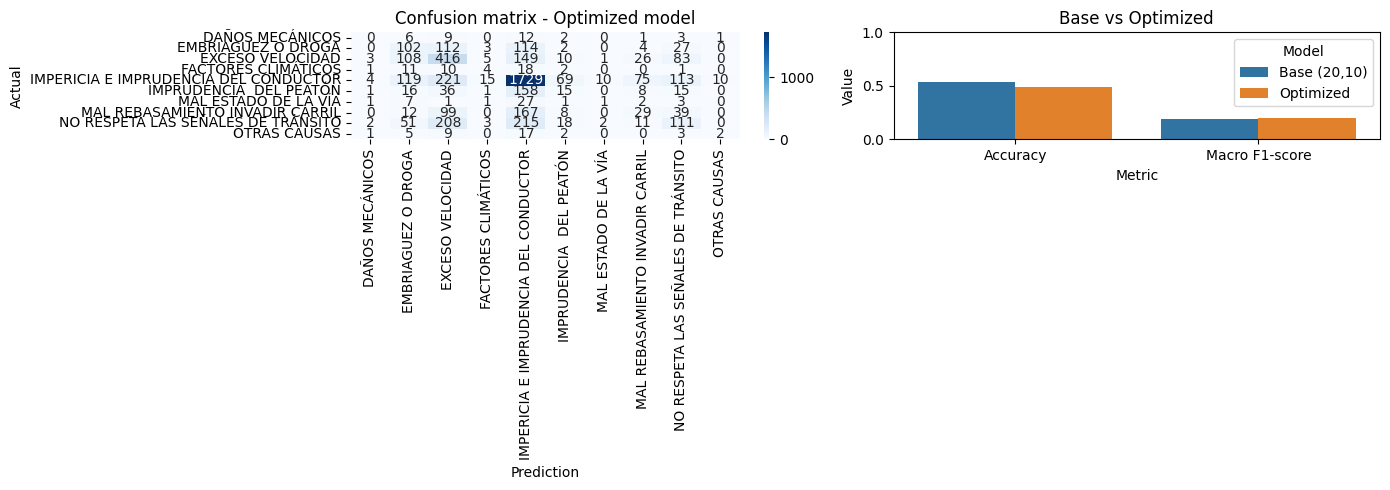

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    conf_best, annot=True, fmt="d", cmap="Blues",
    xticklabels=best_pipeline.classes_,
    yticklabels=best_pipeline.classes_,
    ax=axes[0],
)
axes[0].set_title("Confusion matrix - Optimized model")
axes[0].set_xlabel("Prediction")
axes[0].set_ylabel("Actual")

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro F1-score"],
    "Base (20,10)": [baseline_accuracy, baseline_macro_f1],
    "Optimized": [best_accuracy, best_macro_f1],
}).melt(id_vars="Metric", var_name="Model", value_name="Value")

sns.barplot(data=comparison_df, x="Metric", y="Value", hue="Model", ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_title("Base vs Optimized")

plt.tight_layout()
plt.show()


## Section 3: Exporting the best model's parameters to Excel

We extract from the optimized `Pipeline` (`best_pipeline`) the mathematical components needed to reproduce the forward pass outside of Python: the scaler's means and scales, weight matrices, bias vectors, and the exact class order. Everything is saved into a single Excel workbook with one sheet per component, plus two reference CSV files for the chosen test observation.

In [55]:
best_scaler = best_pipeline.named_steps["scaler"]
best_classifier = best_pipeline.named_steps["classifier"]

print("Optimal architecture (hidden_layer_sizes):", best_classifier.hidden_layer_sizes)
print("Optimal activation function:", best_classifier.activation)
print("Classes (exact order, classes_):", list(best_classifier.classes_))

print("\nShape of the weight matrices (coefs_):")
for i, w in enumerate(best_classifier.coefs_, start=1):
    print(f"  Layer {i}: {w.shape}")

print("\nShape of the bias vectors (intercepts_):")
for i, b in enumerate(best_classifier.intercepts_, start=1):
    print(f"  Layer {i}: {b.shape}")

print("\nScaler means (mean_):\n", best_scaler.mean_)
print("\nScaler scales (scale_):\n", best_scaler.scale_)


Optimal architecture (hidden_layer_sizes): (50,)
Optimal activation function: relu
Classes (exact order, classes_): [np.str_('DAÑOS MECÁNICOS'), np.str_('EMBRIAGUEZ O DROGA'), np.str_('EXCESO VELOCIDAD'), np.str_('FACTORES CLIMÁTICOS'), np.str_('IMPERICIA E IMPRUDENCIA DEL CONDUCTOR'), np.str_('IMPRUDENCIA  DEL PEATÓN'), np.str_('MAL ESTADO DE LA VÍA'), np.str_('MAL REBASAMIENTO INVADIR CARRIL'), np.str_('NO RESPETA LAS SEÑALES DE TRÁNSITO'), np.str_('OTRAS CAUSAS')]

Shape of the weight matrices (coefs_):
  Layer 1: (241, 50)
  Layer 2: (50, 10)

Shape of the bias vectors (intercepts_):
  Layer 1: (50,)
  Layer 2: (10,)

Scaler means (mean_):
 [8.15714576e-02 8.69079081e-02 9.41756455e-02 7.76072372e-02
 7.92844074e-02 8.55356780e-02 8.55356780e-02 8.51799146e-02
 8.07074609e-02 8.59930880e-02 7.28298435e-02 8.46716812e-02
 1.89316934e-01 1.20908721e-01 1.23043301e-01 1.20908721e-01
 1.17096971e-01 1.80473674e-01 1.48251677e-01 3.09514129e-02
 3.44073999e-02 3.04431795e-02 3.03923562e

In [56]:
import os

os.makedirs("weights_and_biases_optimized", exist_ok=True)
excel_path = "weights_and_biases_optimized/optimized_mlp_parameters.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    # Sheet 1: StandardScaler parameters (one row per X column, in the same order)
    pd.DataFrame({
        "feature": X.columns,
        "mean": best_scaler.mean_,
        "scale": best_scaler.scale_,
    }).to_excel(writer, sheet_name="Scaler", index=False)

    # One weights sheet and one biases sheet per layer (hidden layer(s) + output)
    for i, (weights, biases) in enumerate(
        zip(best_classifier.coefs_, best_classifier.intercepts_), start=1
    ):
        pd.DataFrame(weights).to_excel(
            writer, sheet_name=f"Layer{i}_Weights", index=False, header=False
        )
        pd.DataFrame(biases, columns=["bias"]).to_excel(
            writer, sheet_name=f"Layer{i}_Biases", index=False
        )

    # Final sheet: exact class order (position = softmax output index)
    pd.DataFrame({
        "output_index": range(len(best_classifier.classes_)),
        "class": best_classifier.classes_,
    }).to_excel(writer, sheet_name="Classes", index=False)

print(f"Parameters exported to: {excel_path}")
print(f"Total number of layers (hidden + output): {len(best_classifier.coefs_)}")


Parameters exported to: weights_and_biases_optimized/optimized_mlp_parameters.xlsx
Total number of layers (hidden + output): 2


### Test observation for the manual forward pass

We pick one row from the test set (`X_test`) to reproduce its forward pass in Excel. We export its **raw** values (already with `get_dummies`, before standardizing), its true class, and what `predict_proba` predicts in Python, so we can compare at the end (Section 4).

> **Note on encoding, separator, and decimals:** the CSVs are saved with `encoding="utf-8-sig"` (so Excel recognizes accents and the ñ, e.g. `DAÑOS MECÁNICOS`), with `sep=";"`

In [57]:
OBSERVATION_INDEX = 5  # change this index to pick a different row from X_test

x_obs = X_test.iloc[[OBSERVATION_INDEX]]
y_obs_true = y_test.iloc[OBSERVATION_INDEX]

y_obs_pred = best_pipeline.predict(x_obs)[0]
y_obs_proba = best_pipeline.predict_proba(x_obs)[0]

print("Chosen observation (positional index in X_test):", OBSERVATION_INDEX)
print("\nRaw input values (one row, transposed):\n", x_obs.T)
print("\nTrue class:", y_obs_true)
print("Class predicted by Python:", y_obs_pred)
print("\nProbabilities (predict_proba) per class:")
for label, proba in zip(best_pipeline.classes_, y_obs_proba):
    print(f"  {label}: {proba:.6f}")

x_obs.T.to_csv(
    "weights_and_biases_optimized/raw_test_observation.csv",
    header=["value"],
    encoding="utf-8-sig",
    sep=";",
    decimal=",",
)

pd.DataFrame({
    "class": best_pipeline.classes_,
    "python_probability": y_obs_proba,
}).to_csv(
    "weights_and_biases_optimized/python_reference_probabilities.csv",
    index=False,
    encoding="utf-8-sig",
    sep=";",
    decimal=",",
)

print("\nReference files saved. Compare these numbers with your result in Excel (Section 4).")


Chosen observation (positional index in X_test): 5

Raw input values (one row, transposed):
                     562
MES_ABRIL         False
MES_AGOSTO        False
MES_DICIEMBRE     False
MES_ENERO          True
MES_FEBRERO       False
...                 ...
CANTON_ZAMORA     False
CANTON_ZAPOTILLO  False
CANTON_ZARUMA     False
ZONA_RURAL        False
ZONA_URBANA        True

[241 rows x 1 columns]

True class: EMBRIAGUEZ O DROGA
Class predicted by Python: EMBRIAGUEZ O DROGA

Probabilities (predict_proba) per class:
  DAÑOS MECÁNICOS: 0.000917
  EMBRIAGUEZ O DROGA: 0.360711
  EXCESO VELOCIDAD: 0.215945
  FACTORES CLIMÁTICOS: 0.011832
  IMPERICIA E IMPRUDENCIA DEL CONDUCTOR: 0.224072
  IMPRUDENCIA  DEL PEATÓN: 0.069185
  MAL ESTADO DE LA VÍA: 0.012203
  MAL REBASAMIENTO INVADIR CARRIL: 0.062996
  NO RESPETA LAS SEÑALES DE TRÁNSITO: 0.039812
  OTRAS CAUSAS: 0.002327

Reference files saved. Compare these numbers with your result in Excel (Section 4).


## Section 4: Step-by-step guide for the Excel / Google Sheets implementation

This section describes how to structure the spreadsheet to manually reproduce the forward pass for **a single observation** (the row exported in Section 3). One sheet per calculation stage is recommended, although everything can also be done on a single sheet if the blocks are clearly numbered and separated.

> The names used below (`Mean`, `Scale`, `Input`, `W1`, `b1`, etc.) are suggestions. What matters is that each formula references the correct cell of the `optimized_mlp_parameters.xlsx` file exported in Section 3.

### Suggested sheet structure

| Sheet | Content |
|---|---|
| `0_Input` | Raw values of the observation (`feature` column, `value` column) copied from `raw_test_observation.csv` |
| `1_Scaler` | `mean_` and `scale_` per feature (copied from the `Scaler` sheet) and the standardization calculation |
| `2_Layer1` | `Layer1_Weights` matrix, `Layer1_Biases` vector, weighted sum, and activation |
| `3_Layer2` (and following) | Same as above, one sheet per additional hidden layer according to `hidden_layer_sizes` |
| `4_Output` | Matrix and biases of the last layer, scores, `EXP`, sum, and final softmax |

> **Note (actual result from this notebook):** the best model found by `RandomizedSearchCV` has `hidden_layer_sizes=(50,)` and `activation='relu'`, i.e. **a single hidden layer** of 50 neurons feeding directly into the output layer with 10 classes. In practice this means: Step B is applied only once (with `Layer1_Weights`, shape `241x50`, and `Layer1_Biases`, shape `(50,)`), **Step C does not apply** (there are no additional hidden layers to repeat), and Step D directly uses `Layer2_Weights` (shape `50x10`) and `Layer2_Biases` (shape `(10,)`) as the output layer, with the 10 classes listed in the `Classes` sheet.

### Step A - Standardization

On the `1_Scaler` sheet, for each feature $i$ create four columns: `raw_value`, `mean` (`mean_[i]`), `scale` (`scale_[i]`), and `standardized_value`, with the formula:

```
= (raw_value - mean) / scale
```

For example, if the raw value is in `B2`, the mean in `C2`, and the scale in `D2`:

```
E2: =(B2-C2)/D2
```

Copy this formula for all `X` columns (remember: after `pd.get_dummies()`, each category of `MONTH`, `DAY`, `HOUR`, `PROVINCE`, `CANTON`, and `ZONE` is a binary 0/1 column; it is standardized just like any numeric column). The result is the standardized vector $x$, with a length equal to the number of `X` columns after one-hot encoding.

### Step B - Hidden layer 1

For each neuron $j$ of the first hidden layer you need:

$$z^{(1)}_j = \sum_{i} W^{(1)}_{ij} \cdot x_i \; + \; b^{(1)}_j$$

If the standardized vector $x$ is in a column (e.g. `1_Scaler!E2:E(n+1)`) and neuron $j$'s weights are in the corresponding column of `Layer1_Weights` (e.g. `Layer1_Weights!B2:B(n+1)`, since each column of `coefs_[0]` is an output neuron of that layer), use **SUMPRODUCT**:

```
= SUMPRODUCT(1_Scaler!E2:E(n+1), Layer1_Weights!B2:B(n+1)) + Layer1_Biases!B2
```

Repeat this formula for each of the $h_1$ neurons of the first layer, dragging the reference to the corresponding weights column.

Then apply the activation to each $z^{(1)}_j$ to get $a^{(1)}_j$. If `best_classifier.activation` (printed in Section 3) is `'relu'`:

```
= MAX(0, z1_j)
```

(in Spanish-locale Excel/Sheets, the argument separator is `;`: `MAX(0; z1_j)`). If instead it is `'tanh'`, use:

```
= (EXP(z1_j) - EXP(-z1_j)) / (EXP(z1_j) + EXP(-z1_j))
```

which is the definition of $\tanh$ (equivalent to `=TANH(z1_j)` if your Excel/Sheets version includes that function).

### Step C - Subsequent hidden layers

Repeat exactly the Step B procedure, using the previous layer's activation vector as input instead of $x$:

$$z^{(l)}_j = \sum_i W^{(l)}_{ij} \cdot a^{(l-1)}_i + b^{(l)}_j, \qquad a^{(l)}_j = \text{activation}\left(z^{(l)}_j\right)$$

The number of blocks to repeat depends on `best_classifier.hidden_layer_sizes` (Section 3): for example, if the result were `(30, 15)` you would need two blocks (`2_Layer1` with 30 neurons and `3_Layer2` with 15 neurons); if it were `(64, 32, 16)` you would need three blocks. Use the `Layer2_Weights`/`Layer2_Biases`, `Layer3_Weights`/`Layer3_Biases`, etc. sheets exported in Section 3 for each one.

### Step D - Output layer and softmax

The output layer is calculated the same way as the hidden layers (SUMPRODUCT + bias), but **without** applying ReLU/tanh: you get the `scores` $z^{(\text{out})}_k$ directly, one per class $k$, using the weight matrix and biases of the last layer (`LayerN_Weights` / `LayerN_Biases`, where `N` is the total number of layers) and labeling each score with the order from the `Classes` sheet:

```
= SUMPRODUCT(<last_activation_vector>, LayerN_Weights!<column_k>) + LayerN_Biases!<row_k>
```

With the $K$ scores (one per class) in, say, `B2:B(K+1)`, softmax is computed in three columns:

1. **Exponential of each score** (column C):
   ```
   C2: =EXP(B2)
   ```
   drag down to `C(K+1)`.

2. **Sum of all exponentials** (a separate cell, e.g. `E1`):
   ```
   E1: =SUM(C2:C(K+1))
   ```
   (in Spanish-locale Excel/Sheets: `SUMA`).

3. **Softmax probability of each class** (column D), dividing each exponential by the total sum (absolute reference to the sum cell):
   ```
   D2: =C2/$E$1
   ```
   drag down to `D(K+1)`.

Column D is the vector of per-class probabilities: it must sum to 1 and must match (rounding aside) `predict_proba` from Section 3. The class with the maximum probability:

```
= INDEX(Classes!B:B, MATCH(MAX(D2:D(K+1)), D2:D(K+1), 0))
```

(in Spanish-locale Excel/Sheets: `INDICE`/`COINCIDIR`) is the final prediction, equivalent to `.predict()`.

### Final verification

Compare, cell by cell, column D against `python_reference_probabilities.csv` (Section 3). Differences on the order of `1e-6` or smaller are normal (floating-point rounding); large differences almost always indicate a wrong cell reference, a skipped layer, or an activation applied where it shouldn't be (the output layer does **not** get ReLU/tanh before the softmax).

## Section 5: Theoretical deliverables

### 5.1 Comparison table (Base vs Optimized)

| Metric | Base Model `(20, 10)` | Optimized Model |
|---|---|---|
| Architecture (`hidden_layer_sizes`) | (20, 10) | (50,) |
| Activation function | relu | relu |
| Accuracy (test) | 0.5389 | 0.4897 |
| Macro F1-score (test) | 0.1913 | 0.2007 |
| Number of training iterations (`n_iter_`) | 308 | 120 |
| Total number of parameters (weights + biases) | 5160 | 12610 |

**Note:** the optimized model trades some overall accuracy for a better macro F1-score, spreading performance more evenly across minority classes despite `CAUSE`'s imbalance.

### 5.2 Technical limitation and proposed improvement

**Limitation:** one-hot encoding (`pd.get_dummies()`) creates a high-dimensional, sparse input where rare categories are underrepresented, so the MLP can memorize noise instead of general patterns. The model also lacks safety-relevant features like road type or speed.

**Proposed improvement:** replace `pd.get_dummies()` with target encoding or embeddings for high-cardinality variables (e.g. `CANTON`), and use `class_weight` or `SMOTE` to address the `CAUSE` imbalance.

### 5.3 Causality analysis (a large weight is not the same as causation)

A large weight only shows strong influence within the trained model, not a real-world cause. Reasons: (1) the data is observational, so correlations may reflect confounders like traffic volume, not causation; (2) weights aren't uniquely identifiable — different trainings can yield different weights for the same function; (3) a pattern learned via gradient descent isn't a verified causal mechanism. So MLP weights are useful for predicting likely causes, but shouldn't alone justify causal policy claims.

## Part 9: Discussion questions

**Why is accuracy alone insufficient if the classes are imbalanced?**
A model can score high accuracy just by always predicting the majority class while ignoring rare ones; macro F1-score catches that failure, accuracy doesn't.

**What information is lost when categorical variables are replaced by integer codes?**
Integer codes imply an order and distance between categories that doesn't really exist (e.g. `CANTON` 3 isn't "between" 2 and 4), which can mislead the model. One-hot encoding avoids this.

**Why must the same scaler parameters be used at inference time?**
The model's weights were learned assuming the training data's scale; using different means/scales at inference shifts the inputs and produces wrong predictions.

**What does a large weight mean, and what does it not prove about causality?**
It means that input strongly influences one neuron inside this trained model. It does not prove the input causes the outcome, since the data is observational and confounders may explain the pattern.

**When is a transparent Excel implementation useful, and when is it a poor deployment choice?**
It's useful for auditing, teaching, and verifying a model formula by formula. It's a poor choice for production, since it doesn't scale, is error-prone to maintain, and lacks automation/versioning.

**How could you make the experiment more statistically reliable?**
Use repeated or nested cross-validation, more folds and search iterations, and report confidence intervals instead of relying on a single train/test split.